# IMDB Movie Review Sentiment Analysis — Starter Notebook

Fill in every cell marked **`# TODO`**. Do not delete the markdown discussion cells — write your answers directly below the question.

Dataset: [IMDB Dataset of 50K Movie Reviews (Kaggle)](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

See `exercise.md` for full instructions and grading rubric.

## Step 0 — Setup

In [25]:
# TODO: install any missing packages (uncomment if needed)
# !pip install nltk scikit-learn tensorflow pandas matplotlib seaborn

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import nltk
# TODO: download the NLTK resources you need, e.g.:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ISUG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ISUG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ISUG\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ISUG\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## Step 1 — Load & Explore the Data

In [14]:
# TODO: load the CSV you downloaded from Kaggle (e.g. 'IMDB Dataset.csv')
df = None  # TODO: pd.read_csv(...)
df = pd.read_csv ('sentiment/IMDB Dataset.csv')

# TODO: inspect shape, dtypes, and the first few rows
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))

Shape: (50000, 2)

Data Types:
 review       str
sentiment    str
dtype: object

First 3 rows:
                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive



Class counts:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


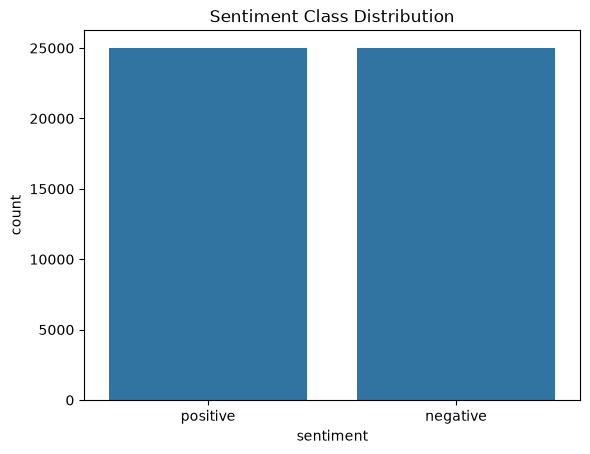

In [15]:
# TODO: check class balance (value_counts on the 'sentiment' column) and plot it as a bar chart

print("\nClass counts:\n", df['sentiment'].value_counts())
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Class Distribution')
plt.show()


In [16]:
# TODO: check for missing values and duplicate reviews. Drop/handle them as appropriate.
print("Missing values:\n", df.isnull().sum())
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Missing values:
 review       0
sentiment    0
dtype: int64
Shape after removing duplicates: (49582, 2)


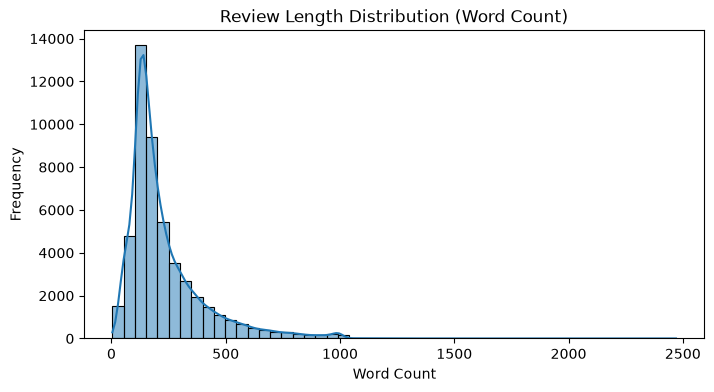

In [17]:
# TODO: compute review length (word count) for every review and plot a histogram.
# You will use this to choose a padding length in Step 5.
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Review Length Distribution (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

## Step 2 — Text Cleaning (Preprocessing Part A)

In [18]:
def clean_text(text: str) -> str:
    """Clean a single raw review string.

    TODO:
      - remove HTML tags (reviews contain '<br />')
      - remove URLs
      - lowercase everything
      - remove punctuation / non-alphabetic characters
      - collapse extra whitespace
    """
    text = re.sub(r'<br\s*/?>', ' ', text)  # remove HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/non-alphabetic
    text = re.sub(r'\s+', ' ', text).strip()  # collapse extra whitespace
    return text

# TODO: apply clean_text to the whole 'review' column and store it in a new column, e.g. 'review_clean'
df['review_clean'] = df['review'].apply(clean_text)

# TODO: print 2-3 examples of (original, cleaned) side by side to sanity check your function
for i in range(2):
    print(f"Original [{i}]: {df['review'].iloc[i][:120]}...")
    print(f"Cleaned  [{i}]: {df['review_clean'].iloc[i][:120]}...\n")

Original [0]: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this...
Cleaned  [0]: one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is e...

Original [1]: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives...
Cleaned  [1]: a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and gives a comforting an...



## Step 3 — Tokenization & Linguistic Preprocessing (Preprocessing Part B)

In [28]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# TODO: choose ONE of these and import it
# from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
# TODO (discussion): decide whether to remove negation words like 'not', 'no', 'never'
# from the stopword set for this task, and explain why in the markdown cell below.
# Retain negation words as they preserve sentiment polarity

negation_words = {'not', 'no', 'nor', 'neither', 'never', 'none', 'cannot'}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def preprocess_tokens(text: str) -> str:
    """Tokenize, remove stopwords, and stem/lemmatize a cleaned review string.

    TODO:
      - tokenize the text
      - remove stopwords
      - apply stemming OR lemmatization
      - rejoin tokens into a single string separated by spaces
    """
    tokens = word_tokenize(text)
    filtered_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    text= ' '.join(filtered_tokens)
    return text

# TODO: apply preprocess_tokens to 'review_clean' and store as 'review_final'
df['review_final'] = df['review_clean'].apply(preprocess_tokens)

df['review_final']

0        one reviewer mentioned watching oz episode you...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49577    thought movie right good job wasnt creative or...
49578    bad plot bad dialogue bad acting idiotic direc...
49579    catholic taught parochial elementary school nu...
49580    im going disagree previous comment side maltin...
49581    no one expects star trek movie high art fan ex...
Name: review_final, Length: 49582, dtype: str

**Discussion (fill in):**
1. Did you remove negation words from your stopword list? Why or why not?
2. Did you choose stemming or lemmatization? What's the trade-off?

yes they are removed, because otherwise they infer positives.


## Step 4 — Encode Labels & Split the Data

In [29]:
# TODO: map 'positive' -> 1, 'negative' -> 0 into a new column 'label'

# TODO: split into train (70%), validation (15%), test (15%) using train_test_split
# with stratify=labels, random_state=SEED. Hint: split twice (train vs temp, then temp -> val/test).

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Train (70%), Validation (15%), Test (15%) splits
X = df['review_final'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, random_state=SEED
)


# TODO: print the size of each split and confirm class balance is preserved in each
print(f"Train set: {len(X_train)} | Pos ratio: {np.mean(y_train):.3f}")
print(f"Val set:   {len(X_val)} | Pos ratio: {np.mean(y_val):.3f}")
print(f"Test set:  {len(X_test)} | Pos ratio: {np.mean(y_test):.3f}")


Train set: 34707 | Pos ratio: 0.502
Val set:   7437 | Pos ratio: 0.502
Test set:  7438 | Pos ratio: 0.502


## Step 5 — Text Vectorization for the Neural Network

In [32]:
VOCAB_SIZE = 15000  # TODO: tune this based on your data
MAX_LEN = 200        # TODO: choose based on your Step 1 histogram

# TODO: fit a Keras Tokenizer ONLY on X_train (never fit on val/test — avoid leakage!)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')

# TODO: tokenizer.fit_on_texts(...)
tokenizer.fit_on_texts(X_train)

# TODO: convert X_train, X_val, X_test to integer sequences with texts_to_sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# TODO: pad/truncate all three sets to MAX_LEN with pad_sequences (padding='post', truncating='post')

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')


## Step 6 — Build the Neural Network

Everyone builds the **same simple architecture** in this exercise:
`Embedding -> GlobalAveragePooling1D -> Dense(16, relu) -> Dropout(0.5) -> Dense(1, sigmoid)`.
No LSTM/GRU/Conv1D needed — see `exercise.md` for why this is the right starting point.

In [38]:
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

EMBEDDING_DIM = 16  # keep small - this is a simple bag-of-embeddings model

# This exercise uses ONE fixed, simple architecture for everyone:
#   Embedding -> GlobalAveragePooling1D -> Dense(16, relu) -> Dropout(0.5) -> Dense(1, sigmoid)
# Do not swap in an LSTM/GRU/Conv1D layer here - see exercise.md Step 6 for why.

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


# TODO: model.summary()

model.summary()


C:\Users\ISUG\anaconda3\envs\AI_Training_2\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Train the Model

In [39]:
# TODO: set up EarlyStopping (monitor='val_loss', patience=..., restore_best_weights=True)
# TODO: optionally set up ModelCheckpoint to save the best model
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

# TODO: history = model.fit(X_train_pad, y_train,
#                            validation_data=(X_val_pad, y_val),
#                            epochs=..., batch_size=..., callbacks=callbacks)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/20
526/543 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6758 - loss: 0.6092

543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6803 - loss: 0.6039 - val_accuracy: 0.8473 - val_loss: 0.4117
Epoch 2/20
530/543 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8513 - loss: 0.3716

543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8522 - loss: 0.3705 - val_accuracy: 0.8774 - val_loss: 0.3073
Epoch 3/20
525/543 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8871 - loss: 0.3000

543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8874 - loss: 0.2996 - val_accuracy: 0.8825 - val_loss: 0.2869
Epoch 4/20
527/543 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9044 - loss: 0.2636

543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9046 - loss: 0.2633 - val_accuracy: 0.8829 - val_loss: 0.2836
Epoch 5/20
541/543 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9198 - loss: 0.2326

543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9199 - loss: 0.2323 - val_accuracy: 0.8880 - val_loss: 0.2757
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9270 - loss: 0.2185 - val_accuracy: 0.8857 - val_loss: 0.2882
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9356 - loss: 0.2014 - val_accuracy: 0.8836 - val_loss: 0.3021
Epoch 8/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9427 - loss: 0.1855 - val_accuracy: 0.8844 - val_loss: 0.3060


## Step 8 — Evaluate

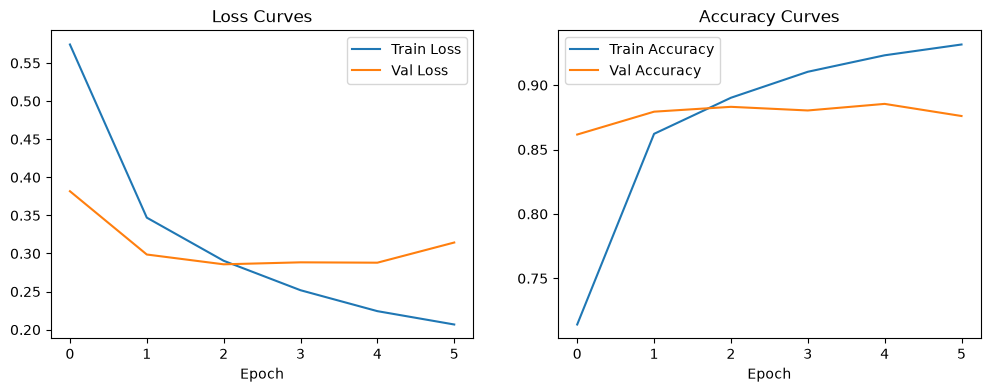

In [37]:
# TODO: plot training vs validation loss (2 lines on one plot) using history.history
# Plot training vs validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.legend()

# Plot training vs validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.legend()
plt.show()

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.85      0.88      3705
    Positive       0.86      0.92      0.89      3733

    accuracy                           0.88      7438
   macro avg       0.89      0.88      0.88      7438
weighted avg       0.89      0.88      0.88      7438



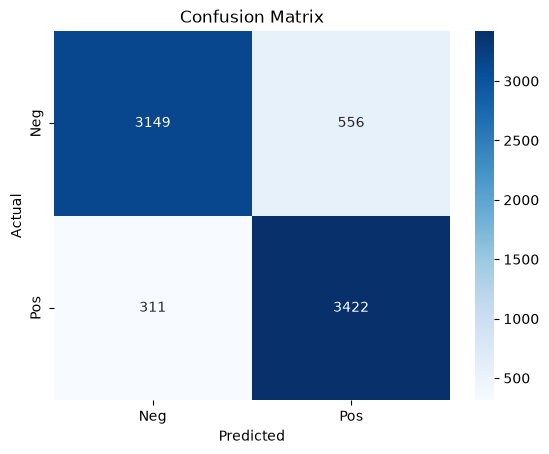

In [36]:
# TODO: get predictions on X_test_pad, threshold at 0.5 to get class labels
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs >= 0.5).astype(int).ravel()

# TODO: print classification_report(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# TODO: compute confusion_matrix(y_test, y_pred) and plot it as a heatmap (seaborn.heatmap)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Discussion (fill in):** Is the model overfitting, underfitting, or well-fit? What evidence from the curves/metrics supports your answer? What would you try next to improve it?

validation_loss begins increasing while train_loss drops further, overfitting occurs.
to improve it (more data ,architecture improvement (more neural ntk), using lstm or gru models, improve early stop)

## Step 9 — Inference on New Reviews

In [42]:
def predict_sentiment(text: str) -> str:
    """Run the FULL pipeline (clean -> tokenize/stopword/stem -> vectorize -> pad -> predict)
    on a single raw review string and return 'positive' or 'negative'.

    TODO: implement using clean_text, preprocess_tokens, tokenizer, pad_sequences, and model.predict
    """
    cleaned = clean_text(text)
    preprocessed = preprocess_tokens(cleaned)
    seq = tokenizer.texts_to_sequences([preprocessed])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)[0][0]
    return 'positive' if pred >= 0.5 else 'negative'
    # return 'positive'

# TODO: test on at least 3 reviews you write yourself:
#   1. clearly positive
#   2. clearly negative
#   3. ambiguous or sarcastic
# and comment on whether the model got them right.
custom_reviews = [
    "Absolute masterpiece! Unbelievable performance and breathtaking visual execution.",
    "Boring, terrible writing, awful acting, and a complete waste of two hours.",
    "It wasn't as bad as everyone claimed, but I certainly wouldn't watch it again."
]

for rev in custom_reviews:
    print(f"Review: \"{rev}\"\nPredicted Sentiment: {predict_sentiment(rev)}\n")

Review: "Absolute masterpiece! Unbelievable performance and breathtaking visual execution."
Predicted Sentiment: positive

Review: "Boring, terrible writing, awful acting, and a complete waste of two hours."
Predicted Sentiment: negative

Review: "It wasn't as bad as everyone claimed, but I certainly wouldn't watch it again."
Predicted Sentiment: negative



## Step 10 — Optional / Bonus

In [43]:
# TODO (optional): build a TF-IDF + Logistic Regression baseline and compare its
# test-set metrics to your neural network's.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE, ngram_range=(1, 2))

# 2. Fit on X_train, transform X_train and X_test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Train Logistic Regression model
baseline_lr = LogisticRegression(max_iter=1000, C=1.0)
baseline_lr.fit(X_train_tfidf, y_train)

# 4. Evaluate on test set
lr_preds = baseline_lr.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"TF-IDF + Logistic Regression Test Accuracy: {lr_acc * 100:.2f}%\n")
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

TF-IDF + Logistic Regression Test Accuracy: 89.49%

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      3705
    Positive       0.88      0.91      0.90      3733

    accuracy                           0.89      7438
   macro avg       0.90      0.89      0.89      7438
weighted avg       0.90      0.89      0.89      7438



In [ ]:
# TODO (optional, not graded): try pretrained GloVe embeddings in your Embedding layer,
# or replace GlobalAveragePooling1D with an LSTM/GRU/Conv1D layer and compare results.
# Only attempt this after your required GlobalAveragePooling1D model in Step 6 is working.
import os
import urllib.request
import zipfile
from tensorflow.keras.layers import LSTM, Bidirectional

# --- Step A: Download & Unzip GloVe Embeddings (50d) ---
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"
glove_file = "glove.6B.50d.txt"

if not os.path.exists(glove_file):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(glove_url, glove_zip)
    print("Extracting GloVe file...")
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
        zip_ref.extract(glove_file)

# --- Step B: Build Embedding Matrix ---
embeddings_index = {}
with open(glove_file, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_dim = 50
embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# --- Step C: Build & Compile LSTM Model with GloVe ---
lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False  # Keep GloVe weights frozen initially
    ),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

# --- Step D: Train LSTM Model ---
lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=lstm_callbacks
)

# --- Step E: Evaluate LSTM Model ---
lstm_preds_probs = lstm_model.predict(X_test_pad)
lstm_preds = (lstm_preds_probs >= 0.5).astype(int).ravel()
lstm_acc = accuracy_score(y_test, lstm_preds)

print(f"\nGloVe + LSTM Test Accuracy: {lstm_acc * 100:.2f}%\n")
print(classification_report(y_test, lstm_preds, target_names=['Negative', 'Positive']))

In [ ]:
# Model comparison table
results_df = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'GlobalAveragePooling1D (Step 6)',
        'GloVe + Bidirectional LSTM'
    ],
    'Test Accuracy': [
        f"{lr_acc * 100:.2f}%",
        f"{accuracy_score(y_test, y_pred) * 100:.2f}%",
        f"{lstm_acc * 100:.2f}%"
    ]
})

print(results_df)